In [73]:
#!/usr/bin/env python
"""
NFL play outcome prediction from frame-level features.

Pipeline:
1. Build play-level outcomes (play_outcomes_gp)
2. Build frame-level features from baseline helmets
3. Add time_since_snap from video metadata
4. Add role features from tracking (position counts + mean speed)
5. Filter/samples frames
6. Train/valid split by game_play (GroupShuffleSplit)
7. Train XGBoost model with class weights + probability calibration
8. Evaluate frame-level and play-level performance
9. Provide helper for real-time frame prediction
"""

import os
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.calibration import CalibratedClassifierCV  # NEW: calibration
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns


# ===========================
# CONFIG
# ===========================

DATA_DIR = "./data/nfl-player-contact-detection/"  # TODO: change this
PLAY_OUTCOMES_FILE = "play_labels.csv"  # must have columns: video_file, label, coarse_label
HELMETS_FILE = "train_baseline_helmets.csv"
VIDEO_META_FILE = "train_video_metadata.csv"
TRACKING_FILE = "train_player_tracking.csv"

FPS = 59.94  # frame rate used in metadata alignment
MIN_TIME_SINCE_SNAP = -4  # seconds; ignore very early frames
N_FRAMES_PER_PLAY = 20     # max frames per play to use for training

RANDOM_STATE = 42
TEST_SIZE = 0.2


# ===========================
# UTILITIES
# ===========================

def load_data():
    play_outcomes = pd.read_csv(os.path.join(DATA_DIR, PLAY_OUTCOMES_FILE))
    helmets = pd.read_csv(os.path.join(DATA_DIR, HELMETS_FILE))
    video_meta = pd.read_csv(os.path.join(DATA_DIR, VIDEO_META_FILE))
    tracking = pd.read_csv(os.path.join(DATA_DIR, TRACKING_FILE))
    return play_outcomes, helmets, video_meta, tracking


def build_play_outcomes_gp(play_outcomes: pd.DataFrame,
                           video_meta: pd.DataFrame) -> pd.DataFrame:
    """
    Map video_file (Sideline/Endzone) -> game_play and collapse to one row per game_play.
    Assumes play_outcomes already has:
      - label (fine)
      - coarse_label (4-class target)
    """
    play_outcomes = play_outcomes.copy()
    video_meta = video_meta.copy()

    # Normalize filenames: strip .mp4
    play_outcomes["video_file_norm"] = (
        play_outcomes["video_file"]
        .str.replace(".mp4", "", regex=False)
        .str.strip()
    )

    video_meta["video_file_norm"] = (
        video_meta["game_key"].astype(str)
        + "_"
        + video_meta["play_id"].astype(str).str.zfill(6)
        + "_"
        + video_meta["view"]
    )

    mapped = play_outcomes.merge(
        video_meta[["game_play", "video_file_norm"]],
        on="video_file_norm",
        how="left",
    )

    mapped = mapped.dropna(subset=["game_play"])

    play_outcomes_gp = (
        mapped[["game_play", "label", "coarse_label"]]
        .drop_duplicates()
    )

    play_outcomes_gp = play_outcomes_gp.dropna(subset=["coarse_label"])

    return play_outcomes_gp


def build_frame_features_from_helmets(helmets: pd.DataFrame) -> pd.DataFrame:
    """
    Build frame-level features from baseline helmets.
    Output has columns: game_play, view, frame, and aggregated bbox stats.
    """
    helmets = helmets.copy()

    # Geometric features per detection
    helmets["area"] = helmets["width"] * helmets["height"]
    helmets["cx"] = helmets["left"] + helmets["width"] / 2.0
    helmets["cy"] = helmets["top"] + helmets["height"] / 2.0
    helmets["aspect_ratio"] = helmets["width"] / helmets["height"].replace(0, np.nan)

    group_cols = ["game_play", "view", "frame"]

    frame_features = (
        helmets.groupby(group_cols)
        .agg(
            num_detections=("nfl_player_id", "size"),
            num_unique_players=("nfl_player_id", pd.Series.nunique),
            area_mean=("area", "mean"),
            area_std=("area", "std"),
            area_min=("area", "min"),
            area_max=("area", "max"),
            width_mean=("width", "mean"),
            width_std=("width", "std"),
            height_mean=("height", "mean"),
            height_std=("height", "std"),
            cx_mean=("cx", "mean"),
            cx_std=("cx", "std"),
            cy_mean=("cy", "mean"),
            cy_std=("cy", "std"),
            aspect_ratio_mean=("aspect_ratio", "mean"),
            aspect_ratio_std=("aspect_ratio", "std"),
        )
        .reset_index()
    )

    return frame_features


def add_time_since_snap(frame_labeled: pd.DataFrame,
                        video_meta: pd.DataFrame) -> pd.DataFrame:
    """
    Add time_since_snap to frame_labeled using video metadata.
    """
    df = frame_labeled.copy()
    video_meta_small = video_meta[["game_play", "view", "snap_time", "start_time"]].copy()

    df = df.merge(video_meta_small, on=["game_play", "view"], how="left")

    df["snap_time"] = pd.to_datetime(df["snap_time"])
    df["start_time"] = pd.to_datetime(df["start_time"])

    df["time_since_video_start"] = df["frame"] / FPS
    df["frame_time"] = df["start_time"] + pd.to_timedelta(
        df["time_since_video_start"], unit="s"
    )

    df["time_since_snap"] = (df["frame_time"] - df["snap_time"]).dt.total_seconds()

    return df


def build_role_features(tracking: pd.DataFrame) -> pd.DataFrame:
    """
    Build play-level role features from tracking:
    - counts per (team, position)
    - mean speed per (team, position)
    """
    tracking = tracking.copy()

    # Counts per team/position
    pos_counts = (
        tracking.groupby(["game_play", "team", "position"])["nfl_player_id"]
        .nunique()
        .reset_index(name="num_players_pos")
    )

    pos_pivot = pos_counts.pivot_table(
        index="game_play",
        columns=["team", "position"],
        values="num_players_pos",
        fill_value=0,
    )
    pos_pivot.columns = [
        f"{team}_{pos}_count" for (team, pos) in pos_pivot.columns
    ]
    pos_pivot = pos_pivot.reset_index()

    # Mean speed per team/position
    speed_agg = (
        tracking.groupby(["game_play", "team", "position"])["speed"]
        .mean()
        .reset_index(name="speed_mean_pos")
    )
    speed_pivot = speed_agg.pivot_table(
        index="game_play",
        columns=["team", "position"],
        values="speed_mean_pos",
    )
    speed_pivot.columns = [
        f"{team}_{pos}_speed_mean" for (team, pos) in speed_pivot.columns
    ]
    speed_pivot = speed_pivot.reset_index()

    role_feat = pos_pivot.merge(speed_pivot, on="game_play", how="outer")

    return role_feat


def sample_frames_per_play(df: pd.DataFrame, n: int, random_state: int = 42) -> pd.DataFrame:
    """
    For each game_play, sample up to n frames (uniformly).
    """
    return (
        df.sort_values("time_since_snap")
          .groupby("game_play", group_keys=False)
          .apply(lambda g: g.sample(min(len(g), n), random_state=random_state))
    )


def train_valid_split(frame_labeled: pd.DataFrame,
                      target_col: str = "coarse_label",
                      test_size: float = TEST_SIZE,
                      random_state: int = RANDOM_STATE):
    """
    Prepare X_train, X_val, y_train, y_val, groups, feature_cols, and label encoder.
    - Filters by time_since_snap
    - Samples frames per play
    - Uses ONLY numeric feature columns (no timestamps)
    """
    # 1) Filter frames after some minimal time since snap
    frame_labeled = frame_labeled[frame_labeled["time_since_snap"] > MIN_TIME_SINCE_SNAP].copy()

    # 2) Sample frames to balance play lengths
    frame_labeled = sample_frames_per_play(
        frame_labeled, N_FRAMES_PER_PLAY, random_state=random_state
    )

    # 3) Identify numeric columns only
    id_cols = ["game_play", "view", "frame"]
    numeric_cols = frame_labeled.select_dtypes(include=[np.number]).columns

    # Exclude id + target from features
    feature_cols = [c for c in numeric_cols if c not in id_cols + [target_col]]

    X = frame_labeled[feature_cols]
    y = frame_labeled[target_col]
    groups = frame_labeled["game_play"]

    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    gss = GroupShuffleSplit(
        n_splits=1, test_size=test_size, random_state=random_state
    )
    train_idx, val_idx = next(gss.split(X, y_encoded, groups=groups))

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]
    y_train = y_encoded[train_idx]
    y_val = y_encoded[val_idx]
    groups_train = groups.iloc[train_idx]
    groups_val = groups.iloc[val_idx]

    return (
        frame_labeled,
        feature_cols,
        le,
        X_train,
        X_val,
        y_train,
        y_val,
        groups_train,
        groups_val,
        train_idx,
        val_idx,
    )


def build_model(feature_cols):
    """
    Build preprocessing + XGB pipeline.
    Uses stronger regularization to reduce overconfidence.
    """
    numeric_features = feature_cols

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", SimpleImputer(strategy="median"), numeric_features),
        ],
        remainder="drop",
    )

    # MORE REGULARIZATION HERE
    model = XGBClassifier(
        n_estimators=200,        # fewer trees -> less overfitting
        max_depth=3,            # shallower trees
        learning_rate=0.05,
        subsample=0.6,          # less data per tree
        colsample_bytree=0.6,   # less features per tree
        min_child_weight=10,    # discourage tiny pure leaves
        reg_lambda=5.0,         # stronger L2 regularization
        reg_alpha=1.0,          # L1 regularization (sparsity)
        gamma=1.0,              # require gain to split
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    clf = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )

    return clf


def compute_class_weights(y_train_encoded, le: LabelEncoder):
    """
    Compute per-sample weights inversely proportional to class frequency.
    """
    labels = pd.Series(le.inverse_transform(y_train_encoded))
    class_counts = labels.value_counts()
    class_weights = 1.0 / class_counts
    class_weights = class_weights / class_weights.mean()
    sample_weights = labels.map(class_weights).values
    return sample_weights


def evaluate_frame_and_play_level(
    clf,
    X_val,
    y_val,
    le: LabelEncoder,
    frame_labeled: pd.DataFrame,
    val_idx: np.ndarray,
):
    """
    Print classification report, confusion matrices (frame & play level).
    """
    y_val_pred = clf.predict(X_val)

    print("Frame-level classification report:")
    print(
        classification_report(
            y_val, y_val_pred, target_names=le.classes_
        )
    )

    cm = confusion_matrix(y_val, y_val_pred)
    cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_df, annot=True, fmt="d")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Frame-level Confusion Matrix")
    plt.tight_layout()
    plt.show()

    # Play-level majority vote
    val_df = frame_labeled.iloc[val_idx].copy()
    val_df["pred_class"] = y_val_pred
    val_df["pred_label"] = le.inverse_transform(y_val_pred)
    val_df["true_label"] = le.inverse_transform(y_val)

    play_preds = (
        val_df.groupby("game_play")
        .agg(
            true_label=("true_label", lambda x: x.iloc[0]),
            pred_label=("pred_label", lambda x: x.value_counts().idxmax()),
        )
        .reset_index()
    )

    play_acc = (play_preds["true_label"] == play_preds["pred_label"]).mean()
    print(f"Play-level accuracy (majority vote over frames): {play_acc:.4f}")

    cm_play = confusion_matrix(
        play_preds["true_label"],
        play_preds["pred_label"],
        labels=le.classes_,
    )
    cm_play_df = pd.DataFrame(cm_play, index=le.classes_, columns=le.classes_)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_play_df, annot=True, fmt="d")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Play-level Confusion Matrix")
    plt.tight_layout()
    plt.show()


def summarize_validation_confidences(clf, X_val, y_val, le: LabelEncoder):
    """
    Print summary stats of top-class probabilities on the validation set.
    This lets you see how calibrated / overconfident the model is.
    """
    proba = clf.predict_proba(X_val)
    top_idx = proba.argmax(axis=1)
    top_conf = proba[np.arange(len(proba)), top_idx]

    print("Top-class confidence stats on validation set:")
    print(pd.Series(top_conf).describe())

    # Optional: per-class stats for the predicted class
    df_conf = pd.DataFrame({
        "top_conf": top_conf,
        "pred_label": le.inverse_transform(top_idx),
    })

    print("\nMean top-class confidence by predicted label:")
    print(df_conf.groupby("pred_label")["top_conf"].mean())


def predict_outcome_for_frame(feature_dict, clf, label_encoder, feature_columns):
    """
    Real-time prediction for a single frame.
    feature_dict: dict {feature_name: value}
    Missing features will be filled with NaN (imputed by pipeline or calibrator->pipeline).
    """
    row = {col: feature_dict.get(col, np.nan) for col in feature_columns}
    df = pd.DataFrame([row])

    proba = clf.predict_proba(df)[0]
    pred_class = clf.predict(df)[0]
    pred_label = label_encoder.inverse_transform([pred_class])[0]

    return pred_label, dict(zip(label_encoder.classes_, proba))


# ===========================
# MAIN
# ===========================

def main():
    # 1. Load raw data
    play_outcomes, helmets, video_meta, tracking = load_data()

    # 2. Play-level outcomes
    play_outcomes_gp = build_play_outcomes_gp(play_outcomes, video_meta)

    # 3. Frame-level features from helmets
    frame_features = build_frame_features_from_helmets(helmets)

    # 4. Attach labels
    frame_labeled = frame_features.merge(
        play_outcomes_gp[["game_play", "coarse_label"]],
        on="game_play",
        how="inner",
    )

    # 5. Add time_since_snap
    frame_labeled = add_time_since_snap(frame_labeled, video_meta)

    # 6. Role features
    role_feat = build_role_features(tracking)
    frame_labeled = frame_labeled.merge(
        role_feat, on="game_play", how="left"
    )

    # 7. Train/valid split (with filtering & sampling)
    (
        frame_labeled,
        feature_cols,
        le,
        X_train,
        X_val,
        y_train,
        y_val,
        groups_train,
        groups_val,
        train_idx,
        val_idx,
    ) = train_valid_split(frame_labeled)

    # 8. Base model (pipeline)
    base_clf = build_model(feature_cols)

    # 9. Class weights
    w_train = compute_class_weights(y_train, le)

    # 10. Fit base model
    base_clf.fit(
        X_train,
        y_train,
        model__sample_weight=w_train,
    )

    # 11. Calibrate probabilities on validation set
    #     This makes predict_proba outputs less extreme.
    calibrated_clf = CalibratedClassifierCV(
        base_estimator=base_clf,
        method="sigmoid",   # or "sigmoid"
        cv="prefit",         # we already fit base_clf
    )
    calibrated_clf.fit(X_val, y_val)

    clf = calibrated_clf  # use calibrated model from here on

    # 12. Evaluation (using calibrated probabilities)
    evaluate_frame_and_play_level(
        clf, X_val, y_val, le, frame_labeled, val_idx
    )

    # 13. Inspect confidence distribution on validation set
    summarize_validation_confidences(clf, X_val, y_val, le)

    # Example real-time usage
    example_frame_features = {
        "num_detections": 15,
        "num_unique_players": 14,
        "area_mean": 320.5,
        "time_since_snap": 1.2,
    }

    pred_label, class_proba = predict_outcome_for_frame(
        example_frame_features, clf, le, feature_cols
    )
    print("Example single-frame prediction:", pred_label)
    print("Example probabilities:", class_proba)

C:\Users\z\AppData\Local\Temp\ipykernel_22476\3231033732.py:226: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), n), random_state=random_state))
C:\Users\z\anaconda3\envs\yoloenv\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['away_K_speed_mean' 'away_LS_speed_mean' 'away_P_speed_mean'
 'home_K_speed_mean' 'home_LS_speed_mean' 'home_P_speed_mean']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Frame-level classification report:
                precision    recall  f1-score   support

 CompletedPass       0.51      0.45      0.48       340
IncompletePass       0.36      0.40      0.38       200
           Run       0.66      0.57      0.61       200
           TFL       0.19      0.33      0.24        60

      accuracy                           0.46       800
     macro avg       0.43      0.44      0.43       800
  weighted avg       0.48      0.46      0.47       800



C:\Users\z\anaconda3\envs\yoloenv\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['away_K_speed_mean' 'away_LS_speed_mean' 'away_P_speed_mean'
 'home_K_speed_mean' 'home_LS_speed_mean' 'home_P_speed_mean']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


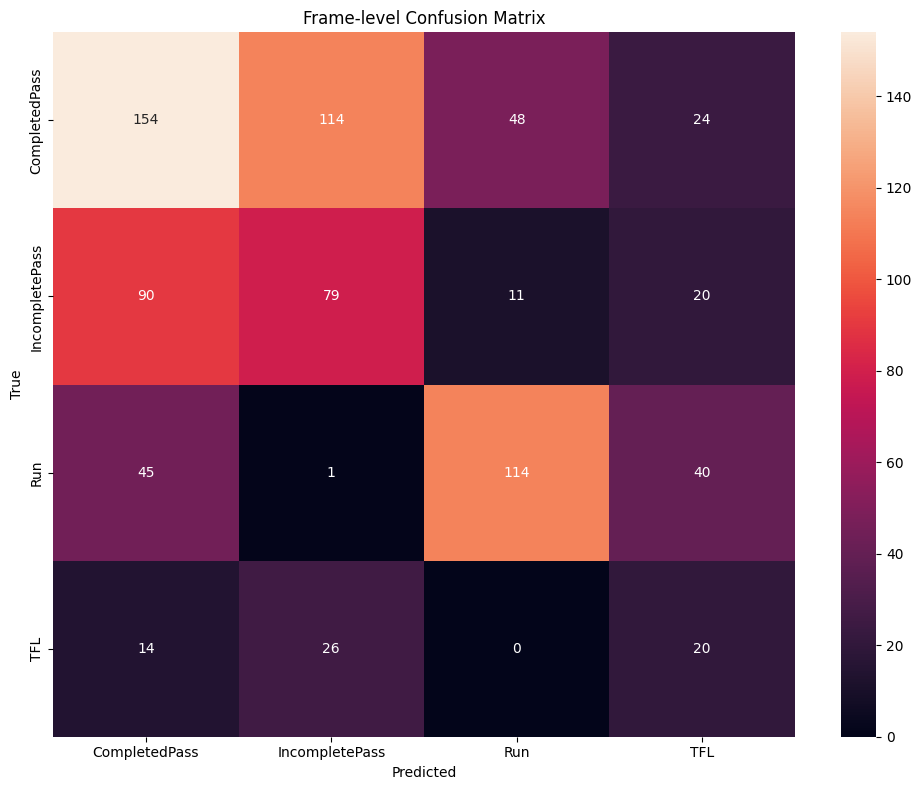

Play-level accuracy (majority vote over frames): 0.4500


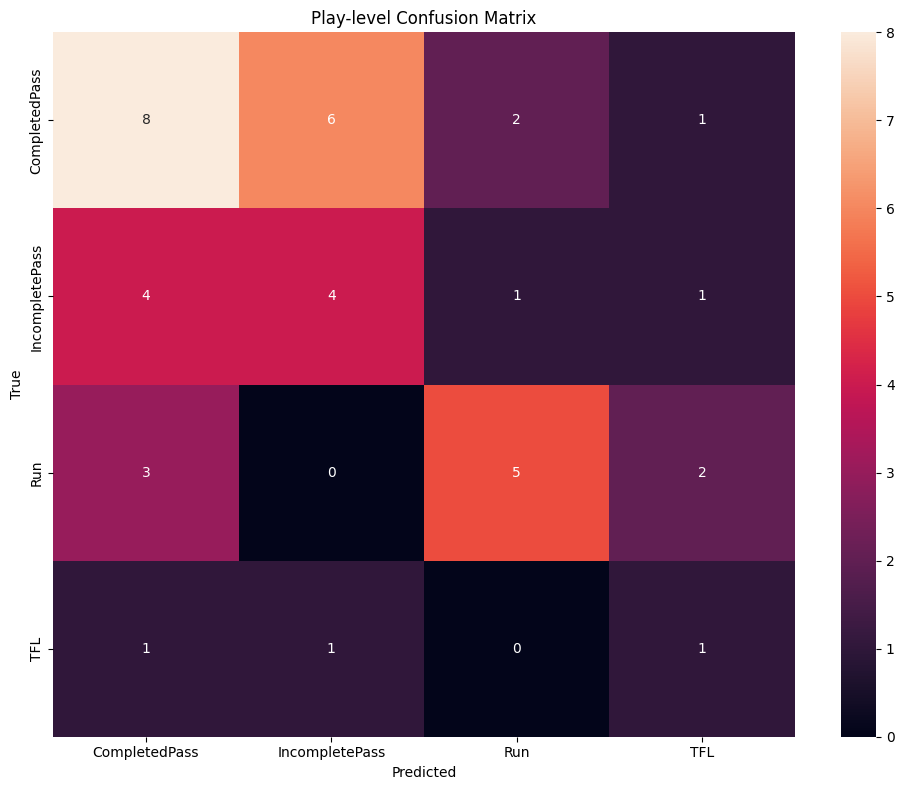

Classes: ['CompletedPass', 'IncompletePass', 'Run', 'TFL']


In [74]:
# 1. Load raw data
play_outcomes, helmets, video_meta, tracking = load_data()

# 2. Play-level outcomes
play_outcomes_gp = build_play_outcomes_gp(play_outcomes, video_meta)

# 3. Frame-level features from helmets
frame_features = build_frame_features_from_helmets(helmets)

# 4. Attach labels (4-class target in 'coarse_label')
frame_labeled = frame_features.merge(
    play_outcomes_gp[["game_play", "coarse_label"]],
    on="game_play",
    how="inner",
)

# Optional: drop "Other" if your coarse_label includes it and you don't want it
frame_labeled = frame_labeled[frame_labeled["coarse_label"] != "Other"].copy()

# 5. Add time_since_snap
frame_labeled = add_time_since_snap(frame_labeled, video_meta)

# 6. Role features
role_feat = build_role_features(tracking)
frame_labeled = frame_labeled.merge(role_feat, on="game_play", how="left")

# 7. Train/valid split (with filtering & sampling)
(
    frame_labeled,
    feature_cols,
    le,
    X_train,
    X_val,
    y_train,
    y_val,
    groups_train,
    groups_val,
    train_idx,
    val_idx,
) = train_valid_split(frame_labeled)

# 8. Model
clf = build_model(feature_cols)

# 9. Class weights
w_train = compute_class_weights(y_train, le)

# 10. Train
clf.fit(
    X_train,
    y_train,
    model__sample_weight=w_train
)

# 11. Evaluation
evaluate_frame_and_play_level(
    clf, X_val, y_val, le, frame_labeled, val_idx
)

print("Classes:", list(le.classes_))


In [75]:
import cv2
import os
import numpy as np

VIDEO_ROOT = "./data/nfl-player-contact-detection/train"  # adjust if needed

def overlay_predictions_on_video_from_frame_labeled(
    game_play: str,
    view: str,
    frame_labeled: pd.DataFrame,
    video_meta: pd.DataFrame,
    out_path: str,
    text_scale: float = 0.7,
    text_thickness: int = 2,
):
    """
    Overlay predicted class + per-class probabilities from frame_labeled
    onto the original video for a given (game_play, view).
    """

    # 1) Slice predictions for this play+view
    df_play = get_play_predictions_from_frame_labeled(game_play, view, frame_labeled)
    df_play_indexed = df_play.set_index("frame")

    # 2) Find video filename from metadata
    meta = video_meta[
        (video_meta["game_play"] == game_play) &
        (video_meta["view"] == view)
    ]

    if meta.empty:
        raise ValueError(f"No video metadata found for {game_play}, view={view}")

    meta_row = meta.iloc[0]

    if "video" in meta_row.index:
        video_file = meta_row["video"]
    else:
        video_file = f"{meta_row['game_key']}_{str(meta_row['play_id']).zfill(6)}_{view}.mp4"

    video_path = os.path.join(VIDEO_ROOT, video_file)
    print("Using video:", video_path)

    if not os.path.exists(video_path):
        raise FileNotFoundError(f"Video file not found: {video_path}")

    # 3) Determine which probability columns exist
    proba_cols = [c for c in df_play.columns if c.startswith("proba_")]
    class_names = [c.replace("proba_", "") for c in proba_cols]

    # 4) Open video and writer
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError(f"Failed to open video {video_path}")

    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps    = cap.get(cv2.CAP_PROP_FPS)
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")

    writer = cv2.VideoWriter(out_path, fourcc, fps, (width, height))

    frame_idx = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_idx in df_play_indexed.index:
            row = df_play_indexed.loc[frame_idx]

            pred_label = row["pred_label"]
            true_label = row.get("coarse_label", None)

            # Box height for header + class probs
            box_height = 25 * (len(class_names) + 3)  # some padding

            cv2.rectangle(
                frame,
                (10, 10),
                (10 + 360, 10 + box_height),
                (0, 0, 0),
                thickness=-1,
            )

            y = 35
            header = f"Frame {frame_idx} | Pred: {pred_label}"
            if true_label is not None:
                header += f" | True: {true_label}"
            cv2.putText(
                frame,
                header,
                (20, y),
                cv2.FONT_HERSHEY_SIMPLEX,
                text_scale,
                (0, 255, 0),
                text_thickness,
                cv2.LINE_AA,
            )
            y += 25

            # Per-class probabilities
            for cls_name, col in zip(class_names, proba_cols):
                p = row[col]
                cv2.putText(
                    frame,
                    f"{cls_name}: {p:.2f}",
                    (20, y),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    text_scale,
                    (255, 255, 255),
                    text_thickness,
                    cv2.LINE_AA,
                )
                y += 22

        writer.write(frame)
        frame_idx += 1

    cap.release()
    writer.release()
    print(f"Annotated video saved to: {out_path}")


In [76]:
import numpy as np
import pandas as pd

def build_play_frame_predictions_full(
    game_play: str,
    view: str,
    clf,
    le,
    feature_cols,
    helmets: pd.DataFrame,
    role_feat: pd.DataFrame,
    video_meta: pd.DataFrame,
    play_outcomes_gp: pd.DataFrame | None = None,
    fps: float = 59.94,
):
    """
    Build frame-level predictions for *all* frames of a given (game_play, view),
    using raw helmets data (no sampling, no time_since_snap filter).
    """

    # 1) Recompute frame-level features for THIS play+view only
    h = helmets[(helmets["game_play"] == game_play) & (helmets["view"] == view)].copy()
    if h.empty:
        raise ValueError(f"No helmet detections for {game_play}, view={view}")

    h["area"] = h["width"] * h["height"]
    h["cx"] = h["left"] + h["width"] / 2.0
    h["cy"] = h["top"] + h["height"] / 2.0
    h["aspect_ratio"] = h["width"] / h["height"].replace(0, np.nan)

    group_cols = ["game_play", "view", "frame"]
    df = (
        h.groupby(group_cols)
         .agg(
             num_detections=("nfl_player_id", "size"),
             num_unique_players=("nfl_player_id", pd.Series.nunique),
             area_mean=("area", "mean"),
             area_std=("area", "std"),
             area_min=("area", "min"),
             area_max=("area", "max"),
             width_mean=("width", "mean"),
             width_std=("width", "std"),
             height_mean=("height", "mean"),
             height_std=("height", "std"),
             cx_mean=("cx", "mean"),
             cx_std=("cx", "std"),
             cy_mean=("cy", "mean"),
             cy_std=("cy", "std"),
             aspect_ratio_mean=("aspect_ratio", "mean"),
             aspect_ratio_std=("aspect_ratio", "std"),
         )
         .reset_index()
    )

    # 2) Add time_since_snap from metadata
    meta = video_meta[(video_meta["game_play"] == game_play) & (video_meta["view"] == view)]
    if meta.empty:
        raise ValueError(f"No video metadata for {game_play}, view={view}")
    m = meta.iloc[0]
    snap_time  = pd.to_datetime(m["snap_time"])
    start_time = pd.to_datetime(m["start_time"])

    df["time_since_video_start"] = df["frame"] / fps
    df["frame_time"] = start_time + pd.to_timedelta(df["time_since_video_start"], unit="s")
    df["time_since_snap"] = (df["frame_time"] - snap_time).dt.total_seconds()

    # 3) Add role features
    df = df.merge(role_feat, on="game_play", how="left")

    # 4) Optional: attach true coarse label
    if play_outcomes_gp is not None:
        df = df.merge(
            play_outcomes_gp[["game_play", "coarse_label"]].drop_duplicates(),
            on="game_play",
            how="left",
        )

    # 5) Use intersection of feature_cols and df columns
    use_cols = [c for c in feature_cols if c in df.columns]
    X_play = df[use_cols]

    # 6) Predict
    proba = clf.predict_proba(X_play)
    pred_idx = proba.argmax(axis=1)
    pred_label = le.inverse_transform(pred_idx)
    pred_conf = proba[np.arange(len(proba)), pred_idx]

    df["pred_label"] = pred_label
    df["pred_conf"] = pred_conf

    for j, cls_name in enumerate(le.classes_):
        df[f"proba_{cls_name}"] = proba[:, j]

    df = df.sort_values("frame").reset_index(drop=True)
    return df


In [77]:
import cv2
import os

VIDEO_ROOT = "./data/nfl-player-contact-detection/train"  # adjust if needed

def overlay_predictions_on_video_full(
    game_play: str,
    view: str,
    df_play: pd.DataFrame,
    video_meta: pd.DataFrame,
    out_path: str,
    text_scale: float = 0.7,
    text_thickness: int = 2,
):
    """
    Overlay predicted class and per-class probabilities from df_play
    (built by build_play_frame_predictions_full) on every frame that
    has helmets for the given (game_play, view).
    """

    df_play_idx = df_play.set_index("frame")

    # Find video path
    meta = video_meta[(video_meta["game_play"] == game_play) & (video_meta["view"] == view)]
    if meta.empty:
        raise ValueError(f"No video metadata for {game_play}, view={view}")
    m = meta.iloc[0]

    if "video" in m.index:
        video_file = m["video"]
    else:
        video_file = f"{m['game_key']}_{str(m['play_id']).zfill(6)}_{view}.mp4"

    video_path = os.path.join(VIDEO_ROOT, video_file)
    print("Using video:", video_path)

    if not os.path.exists(video_path):
        raise FileNotFoundError(video_path)

    proba_cols = [c for c in df_play.columns if c.startswith("proba_")]
    class_names = [c.replace("proba_", "") for c in proba_cols]

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError(f"Failed to open {video_path}")

    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps    = cap.get(cv2.CAP_PROP_FPS)
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(out_path, fourcc, fps, (width, height))

    frame_idx = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_idx in df_play_idx.index:
            row = df_play_idx.loc[frame_idx]

            pred_label = row["pred_label"]
            true_label = row.get("coarse_label", None)

            box_h = 25 * (len(class_names) + 3)
            cv2.rectangle(frame, (10, 10), (10 + 360, 10 + box_h), (0, 0, 0), -1)

            y = 35
            header = f"Frame {frame_idx} | Pred: {pred_label}"
            if true_label is not None:
                header += f" | True: {true_label}"
            cv2.putText(frame, header, (20, y),
                        cv2.FONT_HERSHEY_SIMPLEX, text_scale,
                        (0, 255, 0), text_thickness, cv2.LINE_AA)
            y += 25

            for cls_name, col in zip(class_names, proba_cols):
                p = row[col]
                cv2.putText(frame, f"{cls_name}: {p:.2f}",
                            (20, y),
                            cv2.FONT_HERSHEY_SIMPLEX, text_scale,
                            (255, 255, 255), text_thickness, cv2.LINE_AA)
                y += 22

        writer.write(frame)
        frame_idx += 1

    cap.release()
    writer.release()
    print("Annotated video saved to:", out_path)


In [78]:
# pick one TFL play and one CompletedPass play
tfl_play = play_outcomes_gp[play_outcomes_gp["coarse_label"] == "TFL"]["game_play"].iloc[0]
cp_play  = play_outcomes_gp[play_outcomes_gp["coarse_label"] == "CompletedPass"]["game_play"].iloc[0]

print("TFL play:", tfl_play)
print("CompletedPass play:", cp_play)

# choose a view that exists for both
print("TFL views:", frame_features[frame_features["game_play"] == tfl_play]["view"].value_counts())
print("CP views:", frame_features[frame_features["game_play"] == cp_play]["view"].value_counts())


TFL play: 58168_003392
CompletedPass play: 58174_001792
TFL views: view
Endzone     420
Sideline    420
Name: count, dtype: int64
CP views: view
Endzone     484
Sideline    484
Name: count, dtype: int64


In [79]:
view = "Sideline"

df_tfl = build_play_frame_predictions_full(
    game_play=tfl_play,
    view=view,
    clf=clf,
    le=le,
    feature_cols=feature_cols,
    helmets=helmets,
    role_feat=role_feat,
    video_meta=video_meta,
    play_outcomes_gp=play_outcomes_gp,
)

df_cp = build_play_frame_predictions_full(
    game_play=cp_play,
    view=view,
    clf=clf,
    le=le,
    feature_cols=feature_cols,
    helmets=helmets,
    role_feat=role_feat,
    video_meta=video_meta,
    play_outcomes_gp=play_outcomes_gp,
)

# Inspect how probabilities evolve
proba_cols = [c for c in df_tfl.columns if c.startswith("proba_")]
print("TFL play predictions:")
display(df_tfl[["frame", "time_since_snap", "coarse_label", "pred_label"] + proba_cols].head(20))

print("CompletedPass play predictions:")
display(df_cp[["frame", "time_since_snap", "coarse_label", "pred_label"] + proba_cols].head(20))


C:\Users\z\anaconda3\envs\yoloenv\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['away_K_speed_mean' 'away_LS_speed_mean' 'away_P_speed_mean'
 'home_K_speed_mean' 'home_LS_speed_mean' 'home_P_speed_mean']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


TFL play predictions:


C:\Users\z\anaconda3\envs\yoloenv\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['away_K_speed_mean' 'away_LS_speed_mean' 'away_P_speed_mean'
 'home_K_speed_mean' 'home_LS_speed_mean' 'home_P_speed_mean']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


,frame,time_since_snap,coarse_label,pred_label,proba_CompletedPass,proba_IncompletePass,proba_Run,proba_TFL
0,290,-0.161828,TFL,TFL,0.017055,0.048352,0.041347,0.893247
1,291,-0.145145,TFL,TFL,0.017055,0.048352,0.041347,0.893247
2,292,-0.128462,TFL,TFL,0.017055,0.048352,0.041347,0.893247
3,293,-0.111778,TFL,TFL,0.017055,0.048352,0.041347,0.893247
4,294,-0.095095,TFL,TFL,0.017055,0.048352,0.041347,0.893247
5,295,-0.078412,TFL,TFL,0.017055,0.048352,0.041347,0.893247
6,296,-0.061728,TFL,TFL,0.017055,0.048352,0.041347,0.893247
7,297,-0.045045,TFL,TFL,0.017055,0.048352,0.041347,0.893247
8,298,-0.028362,TFL,TFL,0.017068,0.048391,0.040574,0.893967
9,299,-0.011678,TFL,TFL,0.017055,0.048352,0.041347,0.893247


CompletedPass play predictions:


,frame,time_since_snap,coarse_label,pred_label,proba_CompletedPass,proba_IncompletePass,proba_Run,proba_TFL
0,290,-0.161828,CompletedPass,CompletedPass,0.667990,0.053284,0.197392,0.081334
1,291,-0.145145,CompletedPass,CompletedPass,0.655093,0.051114,0.214029,0.079764
2,292,-0.128462,CompletedPass,CompletedPass,0.655093,0.051114,0.214029,0.079764
3,293,-0.111778,CompletedPass,CompletedPass,0.655093,0.051114,0.214029,0.079764
4,294,-0.095095,CompletedPass,CompletedPass,0.655093,0.051114,0.214029,0.079764
5,295,-0.078412,CompletedPass,CompletedPass,0.655093,0.051114,0.214029,0.079764
6,296,-0.061728,CompletedPass,CompletedPass,0.659850,0.051486,0.208321,0.080343
7,297,-0.045045,CompletedPass,CompletedPass,0.655093,0.051114,0.214029,0.079764
8,298,-0.028362,CompletedPass,CompletedPass,0.654027,0.051031,0.215308,0.079634
9,299,-0.011678,CompletedPass,CompletedPass,0.661266,0.050200,0.210198,0.078336


In [80]:
overlay_predictions_on_video_full(
    game_play=tfl_play,
    view=view,
    df_play=df_tfl,
    video_meta=video_meta,
    out_path=f"./annotated_{tfl_play}_{view}_TFL.mp4",
)

overlay_predictions_on_video_full(
    game_play=cp_play,
    view=view,
    df_play=df_cp,
    video_meta=video_meta,
    out_path=f"./annotated_{cp_play}_{view}_CP.mp4",
)


Using video: ./data/nfl-player-contact-detection/train\58168_003392_Sideline.mp4
Annotated video saved to: ./annotated_58168_003392_Sideline_TFL.mp4
Using video: ./data/nfl-player-contact-detection/train\58174_001792_Sideline.mp4
Annotated video saved to: ./annotated_58174_001792_Sideline_CP.mp4


In [81]:
def summarize_play_probs(df_play: pd.DataFrame):
    """
    Print per-frame probabilities and overall stats for a play.
    """
    proba_cols = [c for c in df_play.columns if c.startswith("proba_")]
    cols_to_show = ["frame", "time_since_snap", "coarse_label", "pred_label"] + proba_cols

    print("First 30 frames for this play:")
    display(df_play[cols_to_show].head(30))

    print("\nSummary stats for per-class probabilities over all frames:")
    display(df_play[proba_cols].describe().T)


In [82]:
# For some play and view you already have
df_play = build_play_frame_predictions_full(
    game_play=tfl_play,
    view="Sideline",
    clf=clf,
    le=le,
    feature_cols=feature_cols,
    helmets=helmets,
    role_feat=role_feat,
    video_meta=video_meta,
    play_outcomes_gp=play_outcomes_gp,
)

summarize_play_probs(df_play)


First 30 frames for this play:


C:\Users\z\anaconda3\envs\yoloenv\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['away_K_speed_mean' 'away_LS_speed_mean' 'away_P_speed_mean'
 'home_K_speed_mean' 'home_LS_speed_mean' 'home_P_speed_mean']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


,frame,time_since_snap,coarse_label,pred_label,proba_CompletedPass,proba_IncompletePass,proba_Run,proba_TFL
0,290,-0.161828,TFL,TFL,0.017055,0.048352,0.041347,0.893247
1,291,-0.145145,TFL,TFL,0.017055,0.048352,0.041347,0.893247
2,292,-0.128462,TFL,TFL,0.017055,0.048352,0.041347,0.893247
3,293,-0.111778,TFL,TFL,0.017055,0.048352,0.041347,0.893247
4,294,-0.095095,TFL,TFL,0.017055,0.048352,0.041347,0.893247
5,295,-0.078412,TFL,TFL,0.017055,0.048352,0.041347,0.893247
6,296,-0.061728,TFL,TFL,0.017055,0.048352,0.041347,0.893247
7,297,-0.045045,TFL,TFL,0.017055,0.048352,0.041347,0.893247
8,298,-0.028362,TFL,TFL,0.017068,0.048391,0.040574,0.893967
9,299,-0.011678,TFL,TFL,0.017055,0.048352,0.041347,0.893247



Summary stats for per-class probabilities over all frames:


,count,mean,std,min,25%,50%,75%,max
proba_CompletedPass,420.0,0.017750,0.001253,0.016407,0.016498,0.017507,0.019228,0.020537
proba_IncompletePass,420.0,0.045038,0.006228,0.033579,0.040115,0.046932,0.049205,0.053017
proba_Run,420.0,0.043818,0.007033,0.031443,0.035947,0.045537,0.050254,0.055997
proba_TFL,420.0,0.893394,0.010707,0.875976,0.885712,0.887648,0.898620,0.913803


In [94]:
from pathlib import Path

def video_path_to_game_play_and_view(video_path: str, video_meta: pd.DataFrame):
    """
    Parse '58187_001383_Sideline.mp4' -> (game_play, view) using train_video_metadata.
    """
    stem = Path(video_path).stem  # e.g. "58187_001383_Sideline"
    parts = stem.split("_")
    if len(parts) < 3:
        raise ValueError(f"Unexpected video filename format: {stem}")

    game_key = int(parts[0])
    play_id  = int(parts[1])
    view     = parts[2]

    meta_row = video_meta[
        (video_meta["game_key"] == game_key) &
        (video_meta["play_id"] == play_id) &
        (video_meta["view"] == view)
    ]
    if meta_row.empty:
        raise ValueError(f"No metadata match for {stem}")
    game_play = meta_row["game_play"].iloc[0]
    return game_play, view


In [95]:
game_play, view_from_name = video_path_to_game_play_and_view("./data/videos/58187_001383_Sideline.mp4", video_meta)
print("Using game_play:", game_play, "view:", view_from_name)

df_play_outcome = build_play_frame_predictions_full(
    game_play=game_play,
    view=view_from_name,
    clf=clf,
    le=le,
    feature_cols=feature_cols,
    helmets=helmets,
    role_feat=role_feat,
    video_meta=video_meta,
    play_outcomes_gp=play_outcomes_gp,
)

# For fast access inside the loop:
outcome_by_frame = df_play_outcome.set_index("frame")
proba_cols = [c for c in df_play_outcome.columns if c.startswith("proba_")]
class_names = [c.replace("proba_", "") for c in proba_cols]


Using game_play: 58187_001383 view: Sideline


C:\Users\z\anaconda3\envs\yoloenv\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['away_K_speed_mean' 'away_LS_speed_mean' 'away_P_speed_mean' 'home_K_speed_mean' 'home_LS_speed_mean' 'home_P_speed_mean']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [103]:
# ... all your imports and config as before ...
from collections import defaultdict, Counter
import torch

def iou(boxA, boxB):
    # box: (x1, y1, x2, y2)
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interW = max(0, xB - xA)
    interH = max(0, yB - yA)
    interArea = interW * interH
    if interArea <= 0:
        return 0.0

    boxAArea = max(0, boxA[2] - boxA[0]) * max(0, boxA[3] - boxA[1])
    boxBArea = max(0, boxB[2] - boxB[0]) * max(0, boxB[3] - boxB[1])
    union = boxAArea + boxBArea - interArea
    if union <= 0:
        return 0.0

    return interArea / union

# After you have:
VIDEO_PATH = "./data/videos/58187_001383_Sideline.mp4"
# - player_model, field_model loaded
# - video_meta, helmets, role_feat, play_outcomes_gp
# - clf, le, feature_cols
# AND you've run the game_play parsing + df_play_outcome code above.

# Index outcome predictions by frame
outcome_by_frame = df_play_outcome.set_index("frame")
proba_cols = [c for c in df_play_outcome.columns if c.startswith("proba_")]
class_names = [c.replace("proba_", "") for c in proba_cols]

# =========================
# Video properties
# =========================
cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise FileNotFoundError(f"Could not open video: {VIDEO_PATH}")

fps    = cap.get(cv2.CAP_PROP_FPS) or 30.0
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()

pre_snap_frames = int(round(2 * fps))
print(f"FPS: {fps:.2f}, pre-snap frames: {pre_snap_frames}")

# =========================
# Output writer
# =========================
os.makedirs("annotated_videos", exist_ok=True)
video_stem = Path(VIDEO_PATH).stem
out_path = Path("annotated_videos") / f"{video_stem}_annotated_with_outcome.mp4"

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(str(out_path), fourcc, fps, (width, height))

# =========================
# Role freezing state
# =========================
position_counts = defaultdict(Counter)  # tid -> Counter(role)
vote_counts     = defaultdict(int)      # tid -> number of high-conf votes
frozen_roles    = {}                    # tid -> frozen role (string)
frozen          = False

from ultralytics import YOLO

PLAYER_MODEL_WEIGHTS = "runs/detect/football_positions_new_model_simpler_aug/weights/best.pt"
FIELD_MODEL_WEIGHTS  = "runs/detect/football_yolo11n2/weights/best.pt"
NUMBER_MODEL_WEIGHTS = "runs/detect/numbers_and_field/weights/best.pt" 

player_model = YOLO(PLAYER_MODEL_WEIGHTS)
field_model  = YOLO(FIELD_MODEL_WEIGHTS)
number_model = YOLO(NUMBER_MODEL_WEIGHTS)

player_names = player_model.names
field_names  = field_model.names
number_names = number_model.names
device = 0 if torch.cuda.is_available() else "cpu"

FIELD_NUMBER_CLASS_NAMES = {"10", "20", "30", "40", "50"}

frame_idx = 0
results_gen = player_model.track(
    source=VIDEO_PATH,
    imgsz=1280,
    conf=0.25,
    device=device,
    tracker="bytetrack.yaml",
    stream=True,
    persist=True,
)

field_color = (255, 255, 0)
number_color = (120, 120, 120)
position_color_map = {
    "qb":    (0,   0, 255),
    "skill": (0, 255,   0),
    "db":    (255, 0,   0),
    "lb":    (0, 255, 255),
    "center":     (255, 0, 255),
}

def get_color_for_position(pos_name: str):
    return position_color_map.get(pos_name, (0, 255, 0))
def class_id_to_role(cls_id: int) -> str:
    return player_names[cls_id]

# Thresholds from the original tracking script
CONF_THRESHOLD_FOR_VOTE     = 0.5
MIN_VOTES_PER_TRACK_FREEZE  = 8
IOU_MATCH_THRESHOLD         = 0.3


for r in results_gen:
    frame = r.orig_img.copy()  # BGR frame from video

    # 1a) Field detections (hashes/lines/etc., but NOT numbers)
    f_res = field_model(frame)[0]

    if f_res.boxes is not None:  # protect against None
        for box in f_res.boxes:
            cls  = int(box.cls[0])
            conf = float(box.conf[0])
            x1, y1, x2, y2 = map(int, box.xyxy[0])
    
            cls_name = field_names[cls]
            # Skip any class that is a "number" in the field model
            if cls_name in FIELD_NUMBER_CLASS_NAMES:
                continue
    
            label = f"{cls_name} {conf:.2f}"
            cv2.rectangle(frame, (x1, y1), (x2, y2), field_color, 2)
            cv2.putText(frame, label, (x1, max(0, y1 - 4)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, field_color, 2)

    # 1b) Number detections (from separate number model)
    n_res = number_model(frame)[0]
    
    if n_res.boxes is not None:  # protect against None
        for box in n_res.boxes:
            cls  = int(box.cls[0])
            conf = float(box.conf[0])
            x1, y1, x2, y2 = map(int, box.xyxy[0])
    
            num_name = number_names[cls]
            label = f"{num_name} {conf:.2f}"
    
            cv2.rectangle(frame, (x1, y1), (x2, y2), number_color, 2)
            cv2.putText(frame, label, (x1, max(0, y1 - 4)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, number_color, 2)



    # 2) PRE-SNAP: accumulate votes per track id
    if not frozen and frame_idx < pre_snap_frames and boxes is not None:
        for box in boxes:
            if box.id is None:
                continue
            tid  = int(box.id[0])
            cls  = int(box.cls[0])
            conf = float(box.conf[0])
            role = class_id_to_role(cls)

            if conf >= CONF_THRESHOLD_FOR_VOTE:
                position_counts[tid][role] += 1
                vote_counts[tid] += 1

    # Freeze roles at snap (first frame where frame_idx >= pre_snap_frames)
    if (not frozen) and frame_idx >= pre_snap_frames:
        frozen_roles = {}
        for tid, counts in position_counts.items():
            if vote_counts[tid] >= MIN_VOTES_PER_TRACK_FREEZE and counts:
                frozen_role = counts.most_common(1)[0][0]
                frozen_roles[tid] = frozen_role
    
        frozen = True
        print(
            f"Snap at frame {frame_idx}: froze {len(frozen_roles)} players "
            f"(min votes {MIN_VOTES_PER_TRACK_FREEZE}, conf >= {CONF_THRESHOLD_FOR_VOTE})"
        )


    # 3) POST-SNAP + drawing live detections with frozen roles
    if boxes is not None:
        for box in boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            cls  = int(box.cls[0])
            conf = float(box.conf[0])
            role_live = class_id_to_role(cls)
    
            tid = int(box.id[0]) if box.id is not None else None
    
            if frozen and tid is not None and tid in frozen_roles:
                # Use frozen role, ignore live prediction
                role_disp = frozen_roles[tid]
            else:
                # Pre-snap or unfrozen track
                role_disp = role_live
    
            color = get_color_for_position(role_disp)
            label = f"{role_disp} {conf:.2f}"
    
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
            cv2.putText(frame, label, (x1, max(0, y1 - 4)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)



    # 4) ★ Outcome overlay from frame-level model
    if frame_idx in outcome_by_frame.index:
        row = outcome_by_frame.loc[frame_idx]

        # Header box
        box_h = 25 * (len(class_names) + 3)
        cv2.rectangle(frame, (10, 10), (10 + 360, 10 + box_h), (0, 0, 0), -1)

        y = 35
        pred_label = row["pred_label"]
        true_label = row.get("coarse_label", None)
        header = f"Frame {frame_idx} | Pred: {pred_label}"
        if true_label is not None:
            header += f" | True: {true_label}"
        cv2.putText(frame, header, (20, y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7,
                    (0, 255, 0), 2, cv2.LINE_AA)
        y += 25

        for cls_name, col in zip(class_names, proba_cols):
            p = row[col]
            cv2.putText(frame, f"{cls_name}: {p:.2f}",
                        (20, y),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6,
                        (255, 255, 255), 1, cv2.LINE_AA)
            y += 22

    writer.write(frame)
    frame_idx += 1

writer.release()
print(f"Saved annotated video to: {os.path.abspath(out_path)}")

display(Video(str(out_path), embed=True, width=800))


FPS: 59.94, pre-snap frames: 120

video 1/1 (frame 1/893) C:\Users\z\Documents\GitHub\NFL_Play_Outcome_Classifier\data\videos\58187_001383_Sideline.mp4: 736x1280 1 center, 4 dbs, 6 lbs, 1 qb, 5 skills, 19.9ms

0: 736x1280 6 five_hashs, 30 hashs, 1 marker, 6 numbers, 15.6ms
Speed: 4.0ms preprocess, 15.6ms inference, 1.5ms postprocess per image at shape (1, 3, 736, 1280)

0: 64x64 10 0.53, 30 0.21, 40 0.12, 50 0.08, 20 0.06, 4.4ms
Speed: 4.9ms preprocess, 4.4ms inference, 0.0ms postprocess per image at shape (1, 3, 64, 64)
video 1/1 (frame 2/893) C:\Users\z\Documents\GitHub\NFL_Play_Outcome_Classifier\data\videos\58187_001383_Sideline.mp4: 736x1280 1 center, 4 dbs, 6 lbs, 1 qb, 5 skills, 15.0ms

0: 736x1280 6 five_hashs, 29 hashs, 1 marker, 7 numbers, 15.0ms
Speed: 3.9ms preprocess, 15.0ms inference, 1.8ms postprocess per image at shape (1, 3, 736, 1280)

0: 64x64 10 0.60, 30 0.18, 40 0.10, 20 0.07, 50 0.06, 5.2ms
Speed: 4.8ms preprocess, 5.2ms inference, 0.0ms postprocess per image at s

NameError: name 'Video' is not defined